In [1]:
# Libraries we are using here
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
# RFM & CLV
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.plotting import plot_period_transactions
# Sklearn
from sklearn.preprocessing import MinMaxScaler
import warnings 
warnings.filterwarnings("ignore")
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: '%.3f' % x)
print(" All libraries loaded.")


 All libraries loaded.


In [2]:
import mysql.connector
import pandas as pd

In [3]:
#  MySQL connector
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="anubrata",
    database="online_retail_db"
)

In [4]:
# Load dataset
query = "SELECT * FROM clean_transactions"
df = pd.read_sql(query, conn)

In [5]:
# Alternate way to Load Dataset
# df = pd.read_csv("cleaned_data.csv")

In [6]:
# First view to the dataset (to see 1st 5 rows )
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2024-01-12 08:26:00,2.550,17850,United Kingdom\r
1,536365,71053,WHITE METAL LANTERN,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2024-01-12 08:26:00,2.750,17850,United Kingdom\r
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r


In [7]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2024-01-12 08:26:00,2.550,17850,United Kingdom\r
1,536365,71053,WHITE METAL LANTERN,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2024-01-12 08:26:00,2.750,17850,United Kingdom\r
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2024-01-12 08:26:00,7.650,17850,United Kingdom\r
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2024-01-12 08:26:00,4.250,17850,United Kingdom\r
7,536366,22633,HAND WARMER UNION JACK,6,2024-01-12 08:28:00,1.850,17850,United Kingdom\r
8,536366,22632,HAND WARMER RED POLKA DOT,6,2024-01-12 08:28:00,1.850,17850,United Kingdom\r
9,536368,22960,JAM MAKING SET WITH JARS,6,2024-01-12 08:34:00,4.250,13047,United Kingdom\r


In [8]:
#for last 5 rows
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
391146,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2025-09-12 12:50:00,0.850,12680,France\r
391147,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2025-09-12 12:50:00,2.100,12680,France\r
391148,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2025-09-12 12:50:00,4.150,12680,France\r
391149,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2025-09-12 12:50:00,4.150,12680,France\r
391150,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2025-09-12 12:50:00,4.950,12680,France\r


In [9]:
# to see total no.s of columns and rows
df.shape

(391151, 8)

In [10]:
len(df)

391151

In [11]:
#---------------------  Data Preprocessing  ----------------------

In [12]:

def check_df(dataframe):
    print("------------------- Shape ------------------------")
    print(dataframe.shape)
    print("------------------- Columns ----------------------")
    print(dataframe.columns)
    print("------------------- Types ------------------------")
    print(dataframe.dtypes)
    print("------------------- Head -------------------------")
    print(dataframe.head())
    print("------------------- Tail -------------------------")
    print(dataframe.tail())
    print("------------------- Describe ---------------------")
    print(dataframe.describe().T)

check_df(df)

------------------- Shape ------------------------
(391151, 8)
------------------- Columns ----------------------
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country'],
      dtype='object')
------------------- Types ------------------------
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
CustomerID             object
Country                object
dtype: object
------------------- Head -------------------------
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391151 entries, 0 to 391150
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      391151 non-null  object        
 1   StockCode    391151 non-null  object        
 2   Description  391151 non-null  object        
 3   Quantity     391151 non-null  int64         
 4   InvoiceDate  391151 non-null  datetime64[ns]
 5   Price        391151 non-null  float64       
 6   CustomerID   391151 non-null  object        
 7   Country      391151 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 23.9+ MB


In [14]:

df = df.dropna(subset=['InvoiceDate'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391151 entries, 0 to 391150
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      391151 non-null  object        
 1   StockCode    391151 non-null  object        
 2   Description  391151 non-null  object        
 3   Quantity     391151 non-null  int64         
 4   InvoiceDate  391151 non-null  datetime64[ns]
 5   Price        391151 non-null  float64       
 6   CustomerID   391151 non-null  int64         
 7   Country      391151 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 23.9+ MB


In [16]:
#check missing (null) values
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
dtype: int64

In [17]:
# optional: drop invalid rows
df.dropna(inplace=True)
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
dtype: int64

In [18]:
# Total number of product in the dataset.
print("the sum of product in the dataset:", df["Description"].count())

the sum of product in the dataset: 391151


In [19]:
# Total revenue in the dataset
total_price_of_df = ((df["Quantity"] * df["Price"]).sum()).astype(float)
print("The sum of price in the dataset:", total_price_of_df)

The sum of price in the dataset: 8737277.640000002


In [20]:
# Dataset ordered from highest price to lowest price
df.sort_values(by = "Price", ascending  = False).head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
152958,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2025-10-06 15:33:00,649.500,15098,United Kingdom\r
152949,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2025-10-06 15:28:00,649.500,15098,United Kingdom\r
3628,536835,22655,VINTAGE RED KITCHEN CABINET,1,2024-02-12 18:06:00,295.000,13145,United Kingdom\r
76276,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,2025-03-14 11:38:00,295.000,13452,United Kingdom\r
87361,547814,22656,VINTAGE BLUE KITCHEN CABINET,1,2025-03-25 14:19:00,295.000,13452,United Kingdom\r


In [21]:
# Dataset ordered from lowest price to highest price
df.sort_values(by = "Price", ascending  = True).head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
161726,557492,16045,POPART WOODEN PENCILS ASST,100,2025-06-20 15:08:00,0.040,13717,United Kingdom\r
271681,569893,16045,POPART WOODEN PENCILS ASST,200,2025-06-10 15:51:00,0.040,12627,Germany\r
309080,573405,16045,POPART WOODEN PENCILS ASST,100,2025-10-30 15:55:00,0.040,13822,United Kingdom\r
357501,578126,16045,POPART WOODEN PENCILS ASST,100,2025-11-23 10:32:00,0.040,16900,United Kingdom\r
271994,569900,16045,POPART WOODEN PENCILS ASST,100,2025-06-10 16:17:00,0.040,17651,United Kingdom\r


In [22]:
#Outlier Observations :Define a safe range for values
#  Outlier capping (IQR method)

In [23]:
def outlier_thresholds(dataframe, variable):
    quartile1 = dataframe[variable].quantile(0.01)
    quartile3 = dataframe[variable].quantile(0.99)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

replace_with_thresholds(df, "Quantity")  #Fix outliers in Quantity
replace_with_thresholds(df, "Price")     #Fix outliers in Price column

In [24]:
# ----------------------------- Exploratory Data Analysis --------------------------

In [25]:
#Categorical Variables

cat_cols = [col for col in df.columns if df[col].dtypes =="O"]
cat_but_car = [col for col in df.columns if df[col].nunique() > 100 and df[col].dtypes == "O"]
cat_cols = [col for col in cat_cols if col not in cat_but_car]
cat_cols

['Country']

                        Country  Ratio
Country                               
United Kingdom\r         348872 89.191
Germany\r                  8643  2.210
France\r                   8019  2.050
EIRE\r                     7127  1.822
Spain\r                    2417  0.618
Netherlands\r              2322  0.594
Belgium\r                  1935  0.495
Switzerland\r              1810  0.463
Portugal\r                 1416  0.362
Australia\r                1180  0.302
Norway\r                   1048  0.268
Channel Islands\r           743  0.190
Italy\r                     741  0.189
Finland\r                   647  0.165
Cyprus\r                    601  0.154
Sweden\r                    427  0.109
Austria\r                   384  0.098
Denmark\r                   367  0.094
Poland\r                    325  0.083
Japan\r                     321  0.082
Israel\r                    245  0.063
Unspecified\r               241  0.062
Singapore\r                 215  0.055
Iceland\r                

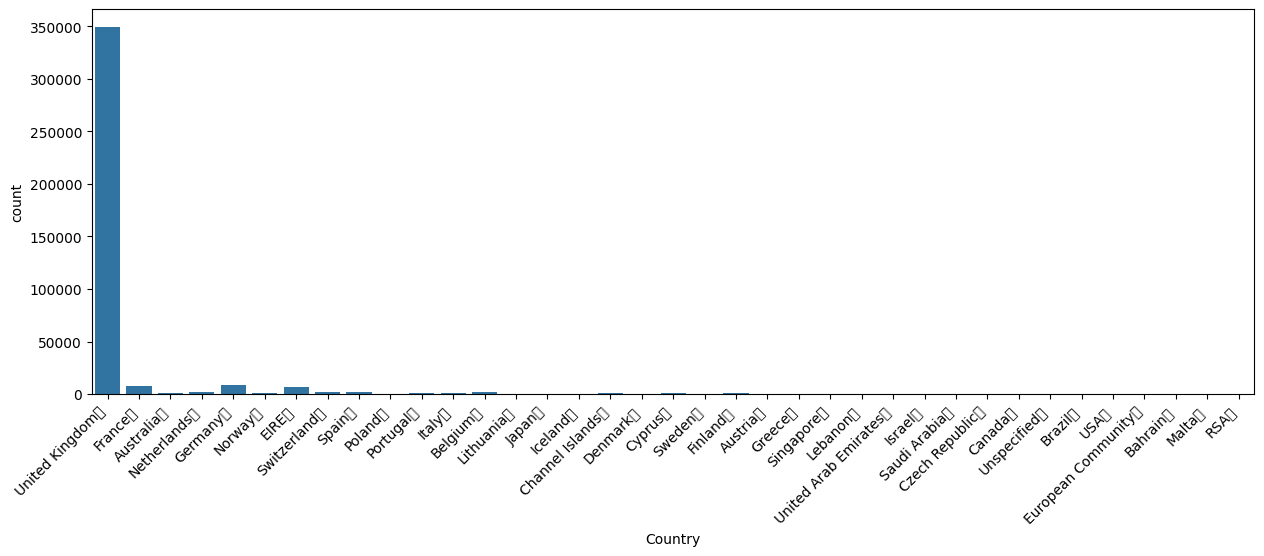

In [26]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("-------------------------------------")
    if plot:
        fig_dims = (15, 5)
        fig, ax = plt.subplots(figsize=fig_dims)
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.xticks(rotation = 45, ha = 'right')
        plt.show()

cat_summary(df, "Country", plot=True)

In [27]:
#Numerical Variables

num_cols = [col for col in df.columns if df[col].dtypes != 'O' and col not in ["CustomerID" , "Invoice"]]
print(num_cols)

['Quantity', 'InvoiceDate', 'Price']


count   391151.000
mean        11.980
std         25.670
min          1.000
5%           1.000
10%          1.000
20%          2.000
30%          2.000
40%          4.000
50%          6.000
60%          8.000
70%         12.000
80%         12.000
90%         24.000
95%         40.000
99%        120.000
max        298.500
Name: Quantity, dtype: float64


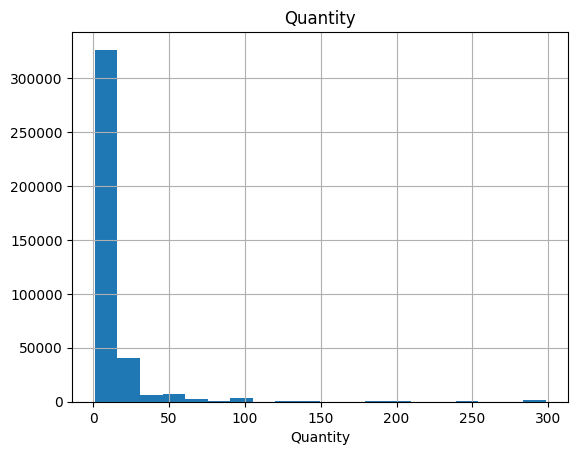

count                           391151
mean     2025-06-21 08:22:07.719985664
min                2024-01-12 08:26:00
5%                 2024-12-14 15:18:00
10%                2025-01-16 16:23:00
20%                2025-03-08 13:39:00
30%                2025-04-15 14:32:00
40%                2025-06-01 13:56:00
50%                2025-07-09 08:18:00
60%                2025-08-15 14:17:00
70%                2025-09-22 18:07:00
80%                2025-10-21 14:41:00
90%                2025-11-16 17:10:00
95%                2025-11-25 12:20:00
99%                2025-12-07 14:17:00
max                2025-12-10 17:19:00
Name: InvoiceDate, dtype: object


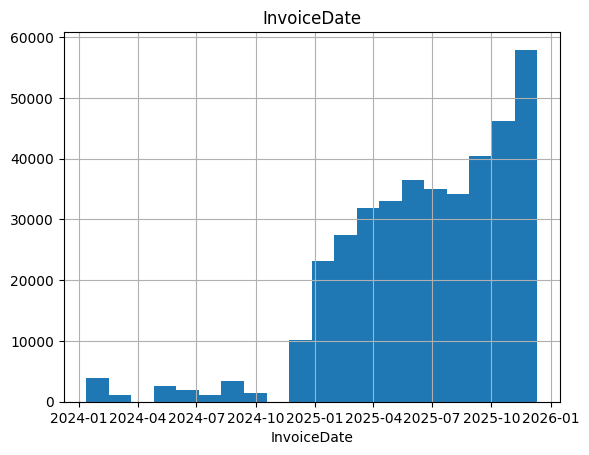

count   391151.000
mean         2.826
std          2.918
min          0.040
5%           0.420
10%          0.550
20%          0.850
30%          1.250
40%          1.650
50%          1.950
60%          2.100
70%          2.950
80%          4.150
90%          6.250
95%          8.500
99%         12.750
max         31.560
Name: Price, dtype: float64


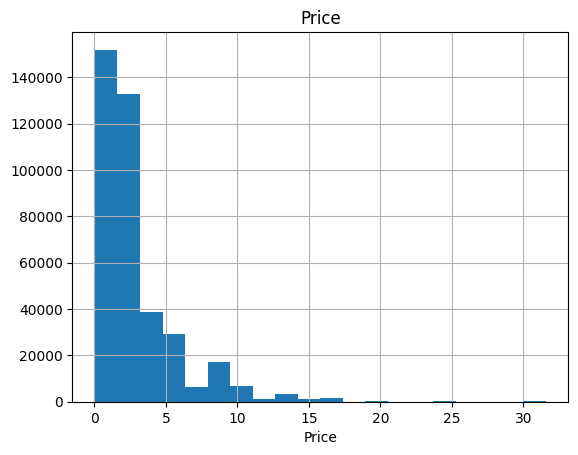

In [28]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()

for col in num_cols:
    num_summary(df, col, plot=True)

In [29]:
# unique product
df["StockCode"].nunique()

3659

In [30]:
# How many sales for each product?
df_product = df.groupby("Description").agg({"Quantity":"count"})
df_product.reset_index(inplace=True)
df_product

,Description,Quantity
0,10 COLOUR SPACEBOY PEN,243
1,12 COLOURED PARTY BALLOONS,142
2,12 DAISY PEGS IN WOOD BOX,66
3,12 EGG HOUSE PAINTED WOOD,64
4,12 HANGING EGGS HAND PAINTED,8
5,12 IVORY ROSE PEG PLACE SETTINGS,92
6,12 MESSAGE CARDS WITH ENVELOPES,194
7,12 PENCIL SMALL TUBE WOODLAND,286
8,12 PENCILS SMALL TUBE RED RETROSPOT,311
9,12 PENCILS SMALL TUBE SKULL,299


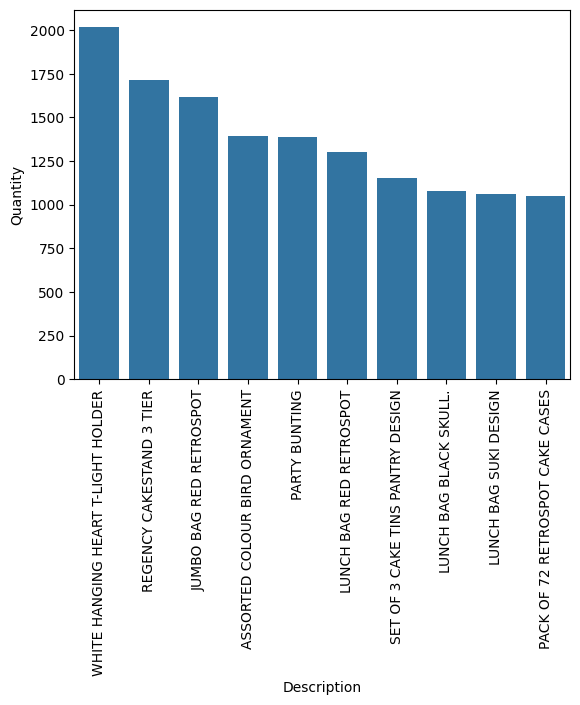

In [31]:
# Top 10 Products by quantity
top_pr= df_product.sort_values(by="Quantity",ascending=False).head(10)

sns.barplot(x="Description", y="Quantity", data=top_pr)
plt.xticks(rotation=90)
plt.show()

In [32]:
# Calculating total price per invoice and adding it.
df["TotalPrice"] = df["Price"] * df["Quantity"]

In [33]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.000,2024-01-12 08:26:00,2.550,17850,United Kingdom\r,15.300
1,536365,71053,WHITE METAL LANTERN,6.000,2024-01-12 08:26:00,3.390,17850,United Kingdom\r,20.340
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.000,2024-01-12 08:26:00,2.750,17850,United Kingdom\r,22.000
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.000,2024-01-12 08:26:00,3.390,17850,United Kingdom\r,20.340
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.000,2024-01-12 08:26:00,3.390,17850,United Kingdom\r,20.340


In [34]:
#  Strip carriage-return from Country  ─
df['Country'] = df['Country'].str.strip()          

# Compute TotalAmount ──
df['TotalAmount'] = df['Quantity'] * df['Price']

# ──  Summary Metrics ───────────────────────────────────────
total_revenue   = df['TotalAmount'].sum()
total_orders    = df['Invoice'].nunique()
total_customers = df['CustomerID'].nunique()
total_products  = df['StockCode'].nunique()
avg_order_value = total_revenue / total_orders

print("=" * 55)
print("        CORE BUSINESS METRICS  –  Consumer360")
print("=" * 55)
print(f"  Total Revenue      : £{total_revenue:>13,.2f}")
print(f"  Total Orders       : {total_orders:>13,}")
print(f"  Unique Customers   : {total_customers:>13,}")
print(f"  Unique Products    : {total_products:>13,}")
print(f"  Avg Order Value    : £{avg_order_value:>13,.2f}")
print("=" * 55)

        CORE BUSINESS METRICS  –  Consumer360
  Total Revenue      : £ 8,104,394.05
  Total Orders       :        18,400
  Unique Customers   :         4,334
  Unique Products    :         3,659
  Avg Order Value    : £       440.46


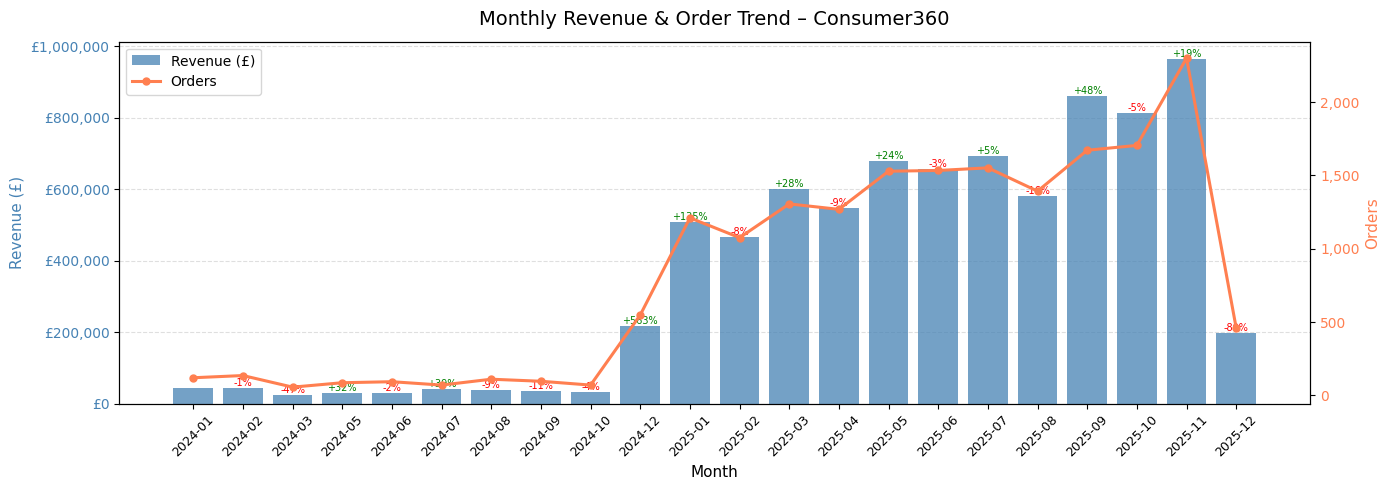

 monthly_trend.png saved.


In [35]:
#------------ Monthly Sales Trend with Month-over-Month (MoM) Growth ----------------
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)
monthly = (
    df.groupby("Month", sort=True)
      .agg(Revenue   = ("TotalPrice", "sum"),
           Orders    = ("Invoice",    "nunique"),
           Customers = ("CustomerID", "nunique"))
      .reset_index()
)
monthly["MoM_Growth_Pct"] = monthly["Revenue"].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

bars = ax1.bar(monthly["Month"], monthly["Revenue"],
               color="steelblue", alpha=0.75, label="Revenue (£)", zorder=2)
line, = ax2.plot(monthly["Month"], monthly["Orders"],
                 color="coral", marker="o", linewidth=2.2,
                 markersize=5, label="Orders", zorder=3)

# MoM growth annotations
for i, row in monthly.iterrows():
    if pd.notna(row["MoM_Growth_Pct"]):
        color = "green" if row["MoM_Growth_Pct"] >= 0 else "red"
        ax1.annotate(
            f"{row['MoM_Growth_Pct']:+.0f}%",
            xy=(i, row["Revenue"]),
            fontsize=7, color=color, ha="center", va="bottom"
        )

ax1.set_xlabel("Month", fontsize=11)
ax1.set_ylabel("Revenue (£)", color="steelblue", fontsize=11)
ax2.set_ylabel("Orders", color="coral", fontsize=11)
ax1.tick_params(axis="x", rotation=45, labelsize=9)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="coral")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"£{x:,.0f}"))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax1.set_title("Monthly Revenue & Order Trend – Consumer360", fontsize=14, pad=12)
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax1.legend([bars, line], ["Revenue (£)", "Orders"], loc="upper left", fontsize=10)
plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print(" monthly_trend.png saved.")


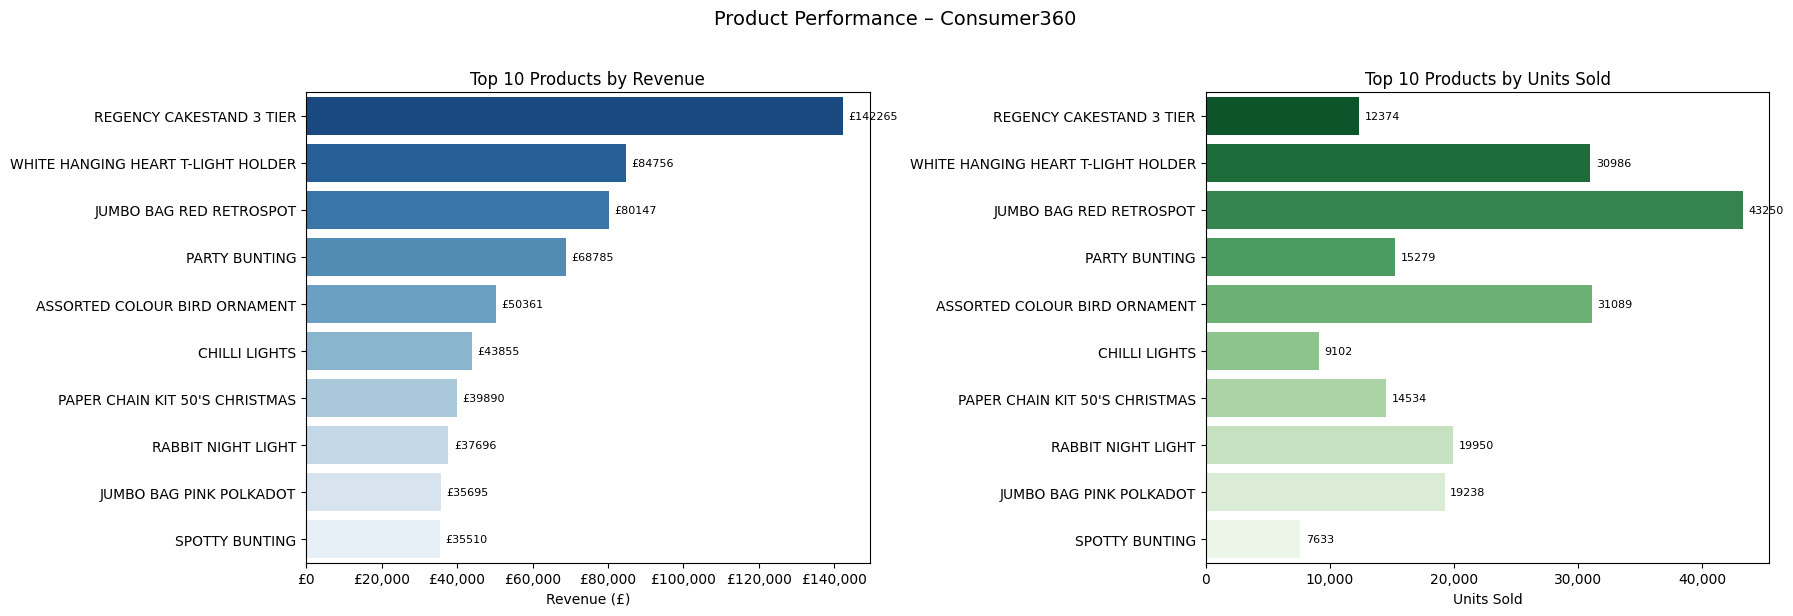

  top_products.png saved.


In [36]:

# ----------------- Top 10 Products by Revenue & Units -------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Top products calculation
top_products = (
    df.groupby('Description')
      .agg(
          Units=('Quantity', 'sum'),
          Revenue=('TotalAmount', 'sum')
      )
      .sort_values('Revenue', ascending=False)
      .head(10)
      .reset_index()
)

# Truncate long descriptions
top_products['Label'] = top_products['Description'].str[:40]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ================= Revenue Chart =================
sns.barplot(
    data=top_products,
    y='Label',
    x='Revenue',
    palette='Blues_r',
    ax=axes[0]
)

axes[0].set_title('Top 10 Products by Revenue', fontsize=12)
axes[0].set_xlabel('Revenue (£)', fontsize=10)
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

# Fix for bar_label error
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='£%.0f', padding=4, fontsize=8)

# ================= Units Chart =================
sns.barplot(
    data=top_products,
    y='Label',
    x='Units',
    palette='Greens_r',
    ax=axes[1]
)

axes[1].set_title('Top 10 Products by Units Sold', fontsize=12)
axes[1].set_xlabel('Units Sold', fontsize=10)
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# Fix for bar_label error
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=4, fontsize=8)

# Final layout
plt.suptitle('Product Performance – Consumer360', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("top_products.png", dpi=150, bbox_inches="tight")
plt.show()
print("  top_products.png saved.")


── Revenue by Country (Top 10) ──────────────────────
       Country       Revenue  Orders  Customers Revenue_Pct
United Kingdom £6,647,027.39   16577       3916      82.02%
   Netherlands   £269,772.46      93          9       3.33%
          EIRE   £254,984.18     256          3       3.15%
       Germany   £205,106.48     443         94       2.53%
        France   £182,238.79     379         87       2.25%
     Australia   £133,645.45      56          9       1.65%
         Spain    £54,462.38      88         30       0.67%
   Switzerland    £52,441.95      47         21       0.65%
       Belgium    £36,918.95      98         25       0.46%
        Sweden    £33,902.04      34          8       0.42%


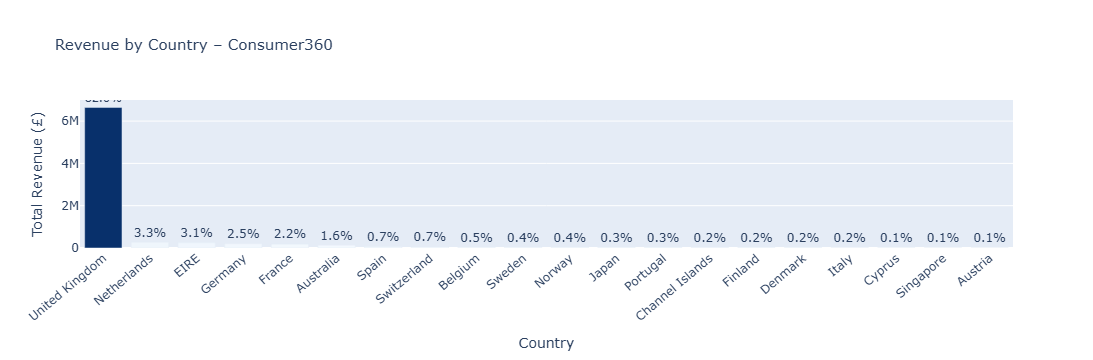

In [37]:

# -------------- Revenue by Country ------------------------

import plotly.express as px 

country_rev = (
    df.groupby('Country')
      .agg(
          Revenue   = ('TotalAmount', 'sum'),
          Orders    = ('Invoice',     'nunique'),
          Customers = ('CustomerID',  'nunique')
      )
      .sort_values('Revenue', ascending=False)
      .reset_index()
)

# Revenue % share
country_rev['Revenue_Pct'] = (
    country_rev['Revenue'] / country_rev['Revenue'].sum() * 100
).round(2)

print("\n── Revenue by Country (Top 10) ──────────────────────")
print(
    country_rev.head(10)
    .to_string(index=False,
               formatters={
                   'Revenue'     : '£{:,.2f}'.format,
                   'Revenue_Pct' : '{:.2f}%'.format
               })
)

# Plotly interactive bar
fig = px.bar(
    country_rev.head(20),
    x='Country',
    y='Revenue',
    color='Revenue',
    color_continuous_scale='Blues',
    text=country_rev.head(20)['Revenue_Pct'].apply(lambda x: f'{x:.1f}%'),
    title='Revenue by Country – Consumer360',
    labels={
        'Revenue': 'Total Revenue (£)',
        'Country': 'Country'
    },
    hover_data={
        'Orders': True,
        'Customers': True,
        'Revenue': ':,.2f'
    }
)

fig.update_traces(textposition='outside')

fig.update_layout(
    xaxis_tickangle=-40,
    coloraxis_showscale=False,
    title_font_size=15
)

fig.show()

In [38]:

# -------------------------------- Quick Sales KPI Summary Table -------------------------- 

kpi_df = pd.DataFrame({
    'Metric'       : ['Total Revenue', 'Total Orders', 'Unique Customers',
                      'Unique Products', 'Avg Order Value',
                      'Date Range Start', 'Date Range End',
                      'Top Country'],
    'Value'        : [
        f'£{total_revenue:,.2f}',
        f'{total_orders:,}',
        f'{total_customers:,}',
        f'{total_products:,}',
        f'£{avg_order_value:,.2f}',
        str(df['InvoiceDate'].min().date()),
        str(df['InvoiceDate'].max().date()),
        country_rev.iloc[0]['Country']
    ]
})

print("\n── KPI Summary ──────────────────────────────────────")
print(kpi_df.to_string(index=False))
print("  Core metrics complete.")


── KPI Summary ──────────────────────────────────────
          Metric          Value
   Total Revenue  £8,104,394.05
    Total Orders         18,400
Unique Customers          4,334
 Unique Products          3,659
 Avg Order Value        £440.46
Date Range Start     2024-01-12
  Date Range End     2025-12-10
     Top Country United Kingdom
  Core metrics complete.


In [39]:
#---------------------------- Customer Segmentation With RFM --------------------------

'''The RFM model is based on three quantitative factors:
1. Recency: How recently a customer has made a purchase
2. Frequency: How often a customer makes a purchase
3. Monetary value: How much money a customer spends on purchases '''

'The RFM model is based on three quantitative factors:\n1. Recency: How recently a customer has made a purchase\n2. Frequency: How often a customer makes a purchase\n3. Monetary value: How much money a customer spends on purchases '

In [40]:
# Preparation of RFM Metrics
''' recency: the difference between today and the customer's last purchase date, in days
    frequency: customer's shopping frequency
    monetary: total money paid by the customer '''

" recency: the difference between today and the customer's last purchase date, in days\n    frequency: customer's shopping frequency\n    monetary: total money paid by the customer "

In [41]:
# Determining the analysis date for the recency
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [42]:
# The final date in the dataset is used as the reference date (‘today’) for recency calculations.
df["InvoiceDate"].max()

Timestamp('2025-12-10 17:19:00')

In [43]:
#This value is used to compute recency values.
today_date = dt.datetime(2025, 12, 11)

In [44]:
# Generating RFM metrics
rfm = df.groupby("CustomerID").agg({"InvoiceDate": lambda InvıiceDate: (today_date- InvıiceDate.max()).days, #Recency Calculation
                                    "Invoice": lambda Invoice: Invoice.nunique(),                             #Frequency Calculation
                                    "TotalPrice": lambda TotalPrice: TotalPrice.sum()})                       #Monetary Calculation

rfm.columns = ["recency","frequency","monetary"]
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
recency,4334.000,105.778,115.098,0.000,22.000,61.000,162.000,698.000
frequency,4334.000,4.246,7.635,1.000,1.000,2.000,5.000,206.000
monetary,4334.000,1869.957,7672.364,3.750,300.597,655.665,1613.905,265029.525


In [45]:
#Generating RFM Scores (Quintile scoring (1=worst, 5=best)) 

In [46]:
# recency_score
rfm["recency_score"] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
# frequency_score
rfm["frequency_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
# monetary_score
rfm["monetary_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5])

#  RFM Score
rfm["RFM_SCORE"] = (rfm["recency_score"].astype(str) + rfm["frequency_score"].astype(str))
rfm.head(10)

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
CustomerID,,,,,,,
12346,326,1,310.440,1,1,2,11
12347,40,7,4310.000,4,5,5,45
12348,76,4,1437.240,3,4,4,34
12349,19,1,1449.160,4,1,4,41
12350,311,1,294.400,1,1,2,11
12352,73,7,1385.740,3,5,4,35
12353,205,1,89.000,1,1,1,11
12354,233,1,1079.400,1,1,4,11
12355,96,1,459.400,2,1,2,21


In [47]:
#Segmenting Customers Based on RFM Scores

In [48]:
# ── Segment mapping ───────────────────────────────────────
seg_map = {
    r"[1-2][1-2]" : "lost",
    r"[1-2][3-4]" : "hibernating",
    r"[1-2]5"     : "cant_lose_them",
    r"3[1-2]"     : "about_to_sleep",
    r"33"         : "needs_attention",
    r"[3-4][4-5]" : "loyal_customers",
    r"41"         : "promising",
    r"51"         : "recent_users",
    r"[4-5][2-3]" : "potential_loyalists",
    r"5[4-5]"     : "champions"
}
rfm["segment"] = rfm["RFM_SCORE"].replace(seg_map, regex=True)

print("\n── RFM Segment Summary ──────────────────────────────────")
print(rfm.groupby("segment")[["recency","frequency","monetary"]]
        .agg(["mean","count"])
        .round(2))


── RFM Segment Summary ──────────────────────────────────
                    recency       frequency       monetary      
                       mean count      mean count     mean count
segment                                                         
about_to_sleep       64.120   333     1.140   333  485.490   333
cant_lose_them      136.740    69     8.230    69 3151.590    69
champions             9.340   665    11.630   665 5904.440   665
hibernating         171.940   587     2.820   587  876.600   587
lost                243.790  1074     1.100  1074  367.700  1074
loyal_customers      42.180   785     6.770   785 2972.400   785
needs_attention      63.760   197     2.380   197  885.270   197
potential_loyalists  20.330   473     2.010   473  676.410   473
promising            28.780    98     1.000    98  362.680    98
recent_users         11.130    53     1.000    53  492.970    53


In [49]:
# Summarize customer behavior for each segment using averages and counts
rfm[["segment", "recency", "frequency", "monetary"]].groupby("segment").agg(["mean", "count"])

recency       frequency       monetary      
                       mean count      mean count     mean count
segment                                                         
about_to_sleep       64.117   333     1.138   333  485.487   333
cant_lose_them      136.739    69     8.232    69 3151.589    69
champions             9.335   665    11.633   665 5904.438   665
hibernating         171.937   587     2.816   587  876.600   587
lost                243.789  1074     1.097  1074  367.698  1074
loyal_customers      42.176   785     6.771   785 2972.401   785
needs_attention      63.756   197     2.381   197  885.270   197
potential_loyalists  20.326   473     2.015   473  676.409   473
promising            28.776    98     1.000    98  362.685    98
recent_users         11.132    53     1.000    53  492.970    53

In [50]:
#Visualization of RFM Segments

In [51]:
# ──  Champions Validation  ───────
print("\n=== VALIDATION: Do Champions represent top spenders? ===")
rfm_reset    = rfm.reset_index()
rfm_reset["spend_rank"] = rfm_reset["monetary"].rank(pct=True)
top20        = rfm_reset[rfm_reset["spend_rank"] >= 0.80]
champ_in_top = (top20["segment"] == "champions").sum()
pct_champ    = champ_in_top / len(top20) * 100
print(f"Top 20% spenders    : {len(top20):,}")
print(f"Of those, Champions : {champ_in_top:,}  ({pct_champ:.1f}%)")
print(f"Validation          : {'PASS' if pct_champ > 35 else '⚠️ REVIEW'} — "
      f"Champions correctly capture high-value customers")



=== VALIDATION: Do Champions represent top spenders? ===
Top 20% spenders    : 867
Of those, Champions : 375  (43.3%)
Validation          : PASS — Champions correctly capture high-value customers


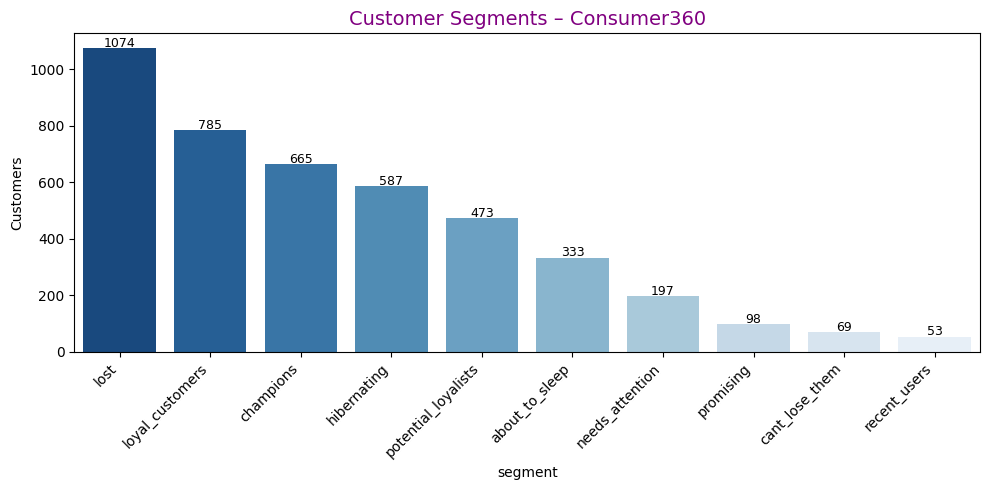

In [52]:
# ──  Segment bar chart ────────────────────────────────────
sgm = rfm["segment"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=sgm.index, y=sgm.values, palette="Blues_r", ax=ax)
ax.set_title("Customer Segments – Consumer360", fontsize=14, color="purple")
ax.set_ylabel("Customers")
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(sgm.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("rfm_segments_bar.png", dpi=150)
plt.show()

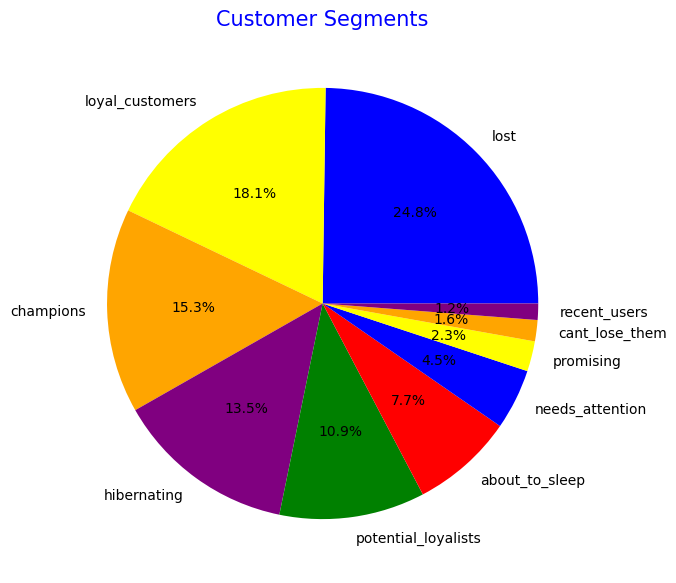

In [53]:
# ──  Pie chart ────────────────────────────────────────────

labels = rfm["segment"].value_counts().index
colors = ['blue','yellow','orange','purple','green','red']
sizes = rfm["segment"].value_counts().values


# visual
plt.figure(figsize = (7,7))
plt.pie(sizes, explode=None, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Customer Segments',color = 'blue',fontsize = 15)
plt.show()

In [54]:
sgm = rfm["segment"].value_counts()

sgm_dict = {k.replace("_", " ").title(): v for k, v in sgm.items()}

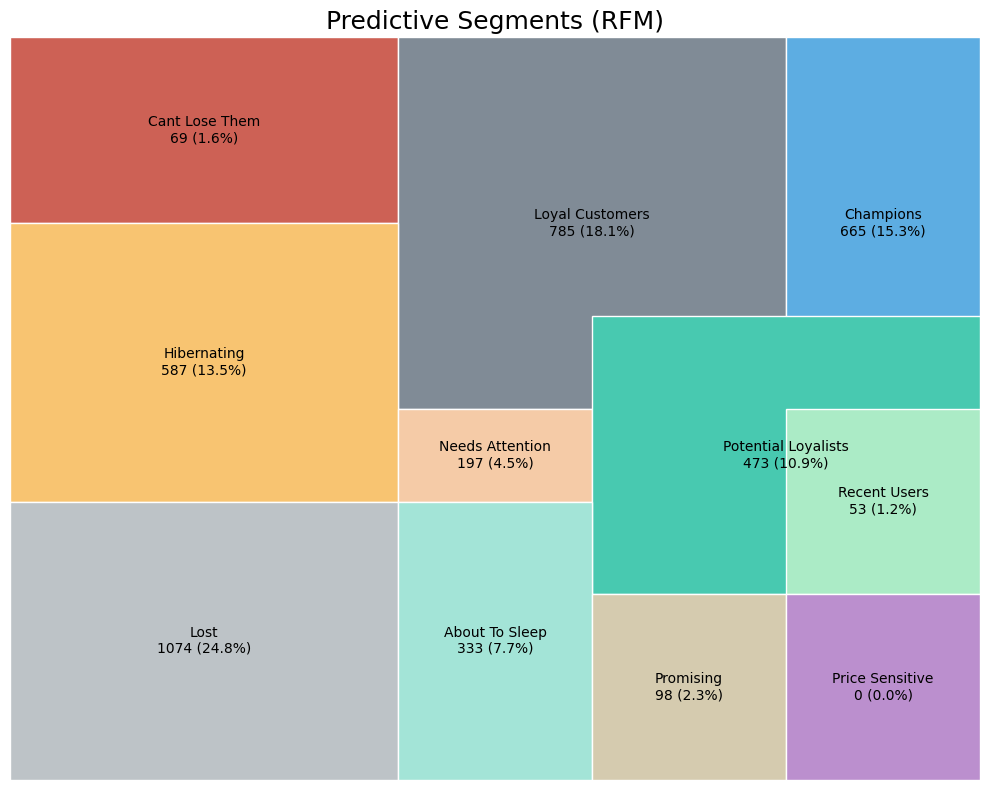

In [55]:
# ---------- RFM Matrix treemap visual (matplotlib) -----------
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 8))

#  total customers
total = sum(sgm_dict.values())

def add_box(x, y, w, h, color, label):
    count = sgm_dict.get(label, 0)
    percent = (count / total) * 100 if total > 0 else 0
    
    text = f"{label}\n{count} ({percent:.1f}%)"
    
    ax.add_patch(Rectangle((x, y), w, h, facecolor=color, edgecolor='white'))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10)

# --- TOP ROW ---
add_box(0, 6, 4, 2, '#CD6155', "Cant Lose Them")
add_box(4, 4, 4, 4, '#808B96', "Loyal Customers")
add_box(8, 4, 2, 4, '#5DADE2', "Champions")

# --- MIDDLE ---
add_box(0, 3, 4, 3, '#F8C471', "Hibernating")
add_box(4, 3, 2, 1, '#F5CBA7', "Needs Attention")
add_box(6, 2, 4, 3, '#48C9B0', "Potential Loyalists")

# --- LOWER ---
add_box(0, 0, 4, 3, '#BDC3C7', "Lost")
add_box(4, 0, 2, 3, '#A3E4D7', "About To Sleep")
add_box(6, 0, 2, 2, '#D5CBAF', "Promising")
add_box(8, 2, 2, 2, '#ABEBC6', "Recent Users")
add_box(8, 0, 2, 2, '#BB8FCE', "Price Sensitive")

# Axis settings
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)

ax.set_xlabel("Recency score", fontsize=12)
ax.set_ylabel("Frequency & Monetary score", fontsize=12)

plt.title("Predictive Segments (RFM)", fontsize=18)
plt.axis('off')

plt.tight_layout()
plt.savefig('Predictive Segments (RFM).png', dpi=150)
plt.show()

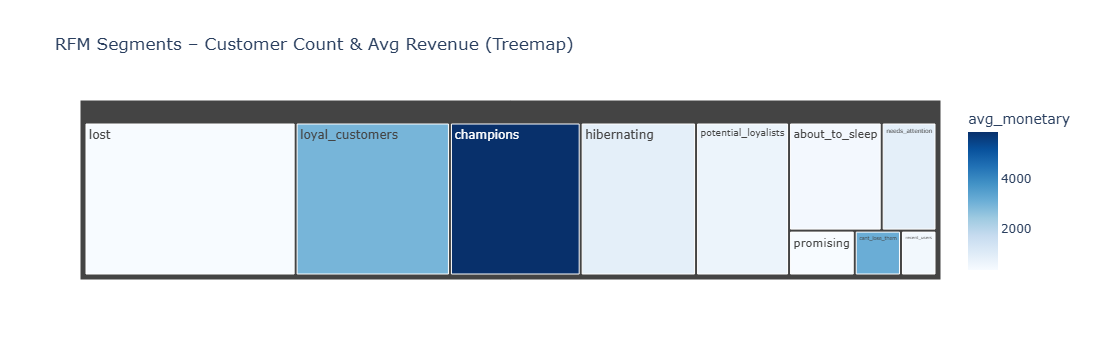

,segment,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
0,about_to_sleep,333,333,333,333,333,333,333
1,cant_lose_them,69,69,69,69,69,69,69
2,champions,665,665,665,665,665,665,665
3,hibernating,587,587,587,587,587,587,587
4,lost,1074,1074,1074,1074,1074,1074,1074
5,loyal_customers,785,785,785,785,785,785,785
6,needs_attention,197,197,197,197,197,197,197
7,potential_loyalists,473,473,473,473,473,473,473
8,promising,98,98,98,98,98,98,98
9,recent_users,53,53,53,53,53,53,53


In [56]:
# ──  Plotly Treemap ───────────────────────────────────────
import plotly.express as px
df_treemap = rfm.groupby("segment").agg(
    customers = ("monetary", "count"),
    avg_monetary = ("monetary", "mean")
).reset_index()

fig = px.treemap(
    df_treemap, path=["segment"],
    values="customers", color="avg_monetary",
    color_continuous_scale="Blues",
    title="RFM Segments – Customer Count & Avg Revenue (Treemap)"
)
fig.write_html("rfm_treemap.html");  fig.show()

df_treemap = rfm.groupby('segment').agg('count').reset_index()
df_treemap.head(10)

In [57]:
# ──  Top spenders analysis ────────────────────────────────
rfm["spend_rank"] = rfm["monetary"].rank(pct=True)
top_spenders = rfm[rfm["spend_rank"] >= 0.80]
print("\n=== Segment distribution in top 20% spenders ===")
print(top_spenders["segment"].value_counts())

print("\n=== Top 10 spenders ===")
print(rfm.nlargest(10, "monetary")
         [["recency_score","frequency_score","monetary_score",
           "monetary","segment"]]
         .to_string())

print("✅  RFM segmentation complete.")



=== Segment distribution in top 20% spenders ===
segment
champions              375
loyal_customers        345
hibernating             49
cant_lose_them          43
potential_loyalists     19
needs_attention         14
lost                    13
about_to_sleep           7
promising                1
recent_users             1
Name: count, dtype: int64

=== Top 10 spenders ===
           recency_score frequency_score monetary_score   monetary          segment
CustomerID                                                                         
14646                  5               5              5 265029.525        champions
18102                  5               5              5 231447.985        champions
14911                  5               5              5 135744.410        champions
17450                  5               5              5 131550.645        champions
12415                  4               5              5 120173.295  loyal_customers
14156                  5         

In [58]:
# ------------------------------- Cohort Analysis ---------------------------------

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391151 entries, 0 to 391150
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      391151 non-null  object        
 1   StockCode    391151 non-null  object        
 2   Description  391151 non-null  object        
 3   Quantity     391151 non-null  float64       
 4   InvoiceDate  391151 non-null  datetime64[ns]
 5   Price        391151 non-null  float64       
 6   CustomerID   391151 non-null  int64         
 7   Country      391151 non-null  object        
 8   TotalPrice   391151 non-null  float64       
 9   TotalAmount  391151 non-null  float64       
 10  Month        391151 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 32.8+ MB


In [60]:
# Assign cohort month
df['cohort_month'] = (df.groupby('CustomerID')['InvoiceDate']
                        .transform('min')
                        .dt.to_period('M'))
df['invoice_period'] = df['InvoiceDate'].dt.to_period('M')
df['period_number'] = (df['invoice_period'] - df['cohort_month']).apply(lambda x: x.n)

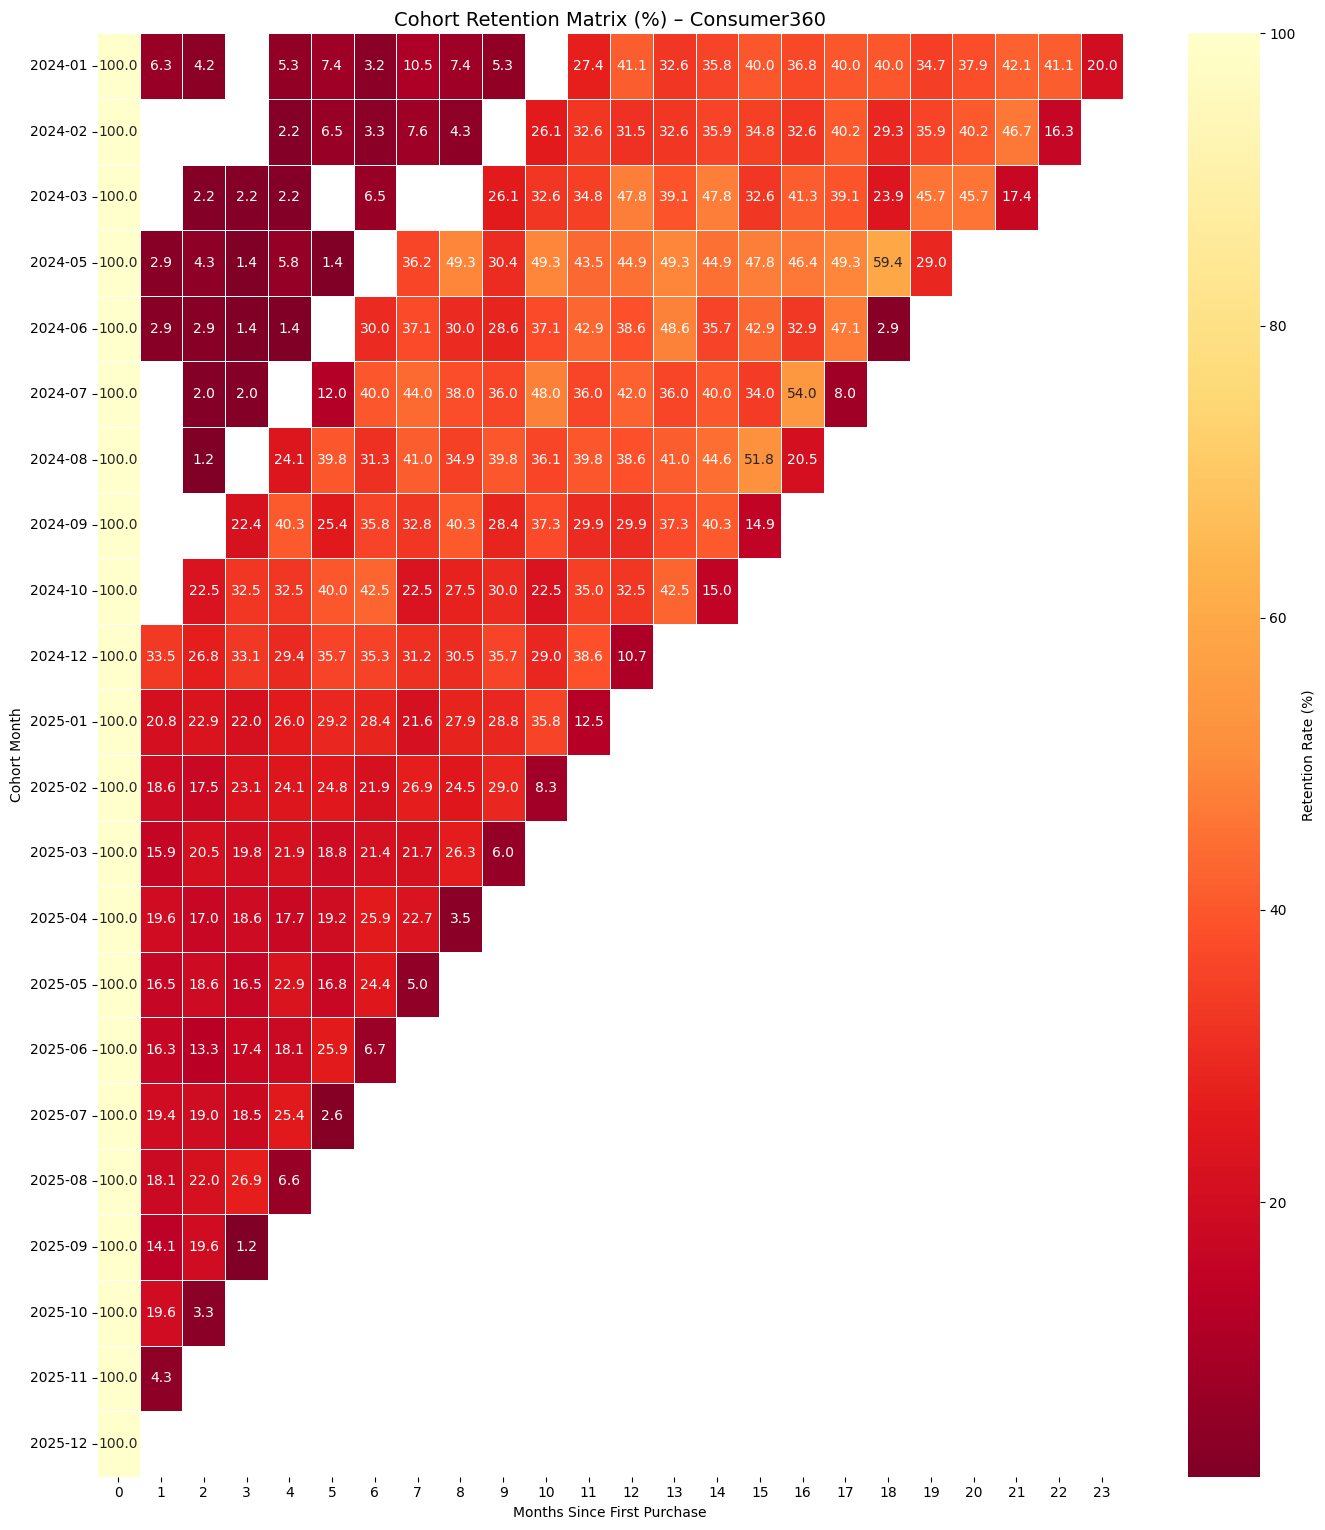

In [61]:
# ──  Customer count retention ─────────────────────────────
cohort_data = (df.groupby(["cohort_month","period_number"])
                 ["CustomerID"].nunique()
                 .reset_index()
                 .rename(columns={"CustomerID":"customers"}))

cohort_pivot = cohort_data.pivot(
    index="cohort_month", columns="period_number", values="customers"
)
cohort_size = cohort_pivot.iloc[:, 0]
retention   = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(14, max(5, len(retention) * 0.7)))
sns.heatmap(retention, annot=True, fmt=".1f",
            cmap="YlOrRd_r", linewidths=0.5,
            cbar_kws={"label": "Retention Rate (%)"}, ax=ax)
ax.set_title("Cohort Retention Matrix (%) – Consumer360", fontsize=14)
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort Month")
plt.tight_layout()
plt.savefig("cohort_retention.png", dpi=150)
plt.show()



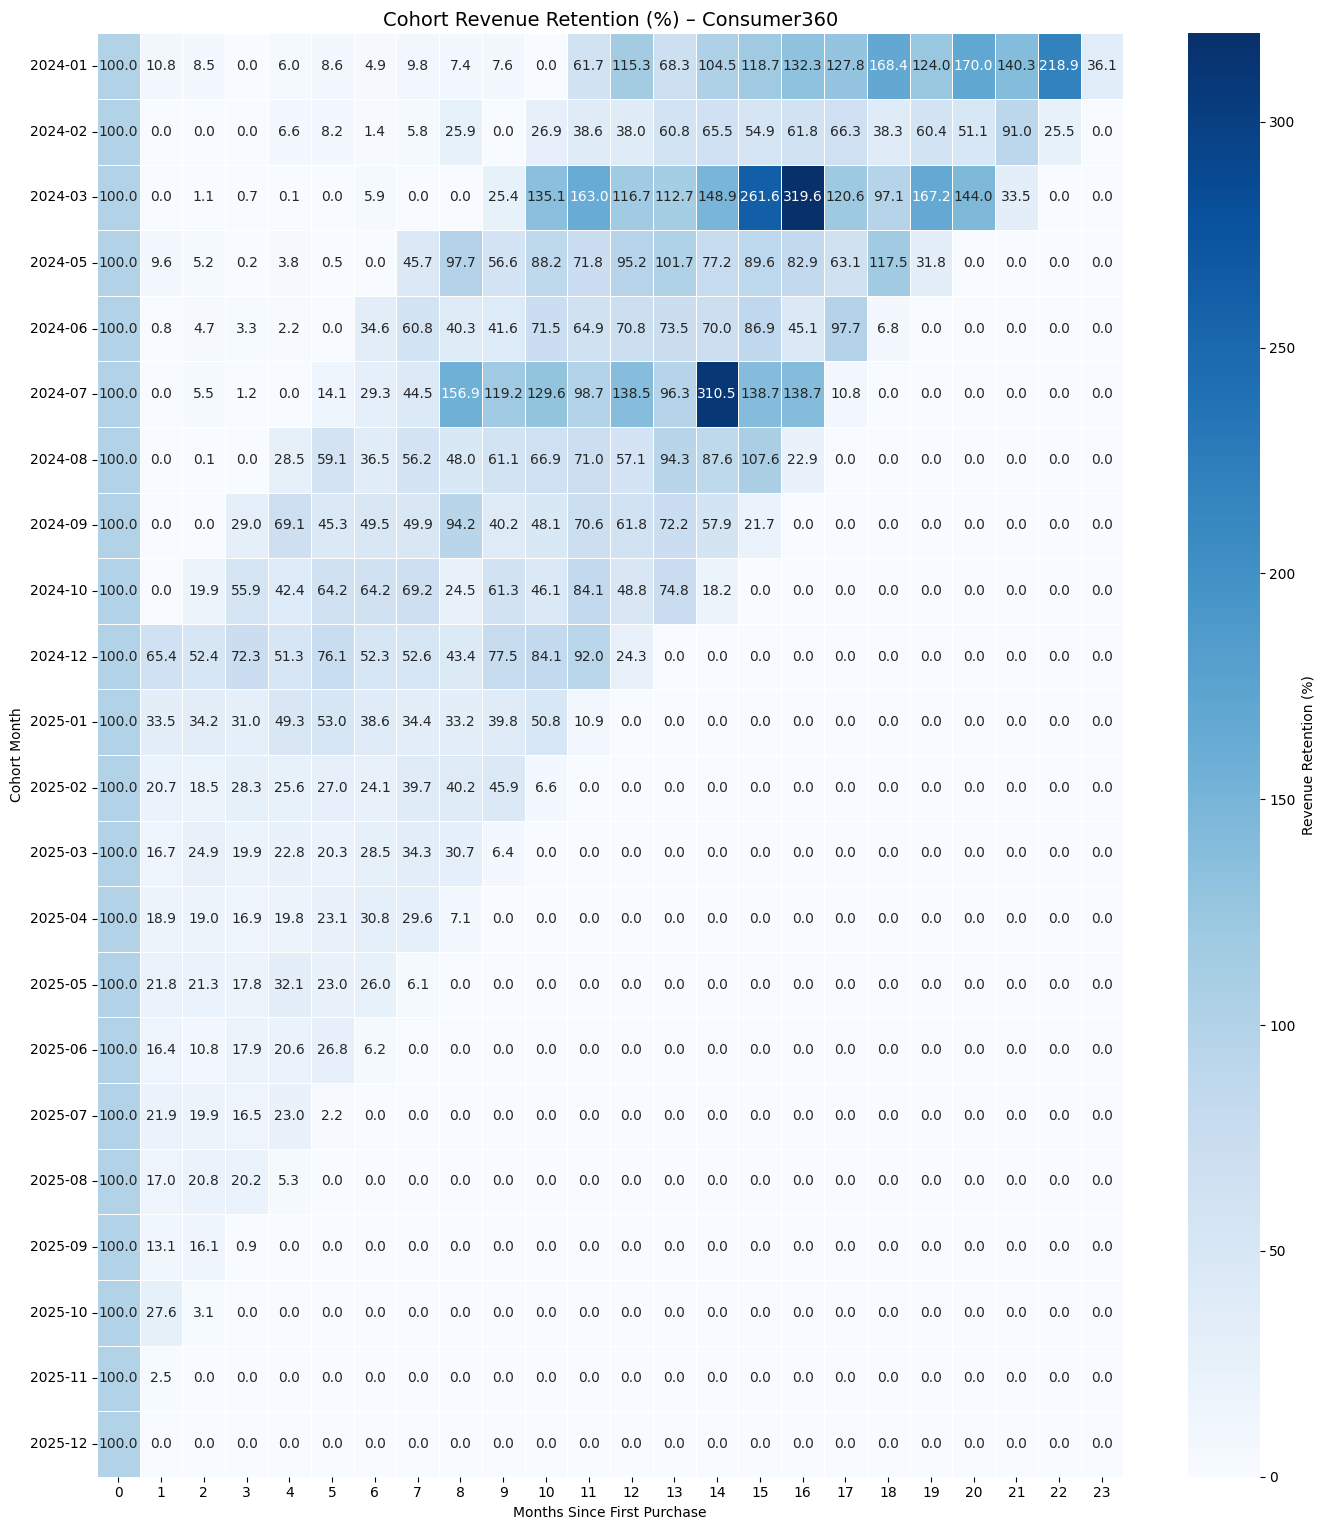

 Cohort analysis complete.


In [62]:
# ──  Revenue cohort ────────────────────────────────────────
rev_cohort = (df.groupby(["cohort_month","period_number"])
                ["TotalPrice"].sum()
                .unstack(fill_value=0))
rev_cohort_pct = (rev_cohort
                  .divide(rev_cohort.iloc[:, 0], axis=0)
                  .round(3) * 100)

fig, ax = plt.subplots(figsize=(14, max(5, len(rev_cohort_pct) * 0.7)))
sns.heatmap(rev_cohort_pct, annot=True, fmt=".1f",
            cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "Revenue Retention (%)"}, ax=ax)
ax.set_title("Cohort Revenue Retention (%) – Consumer360", fontsize=14)
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort Month")
plt.tight_layout()
plt.savefig("cohort_revenue_retention.png", dpi=150)
plt.show()

print(" Cohort analysis complete.")

In [63]:
 # ------------------------Market Basket Analysis (mlxtend Apriori)----------------------

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391151 entries, 0 to 391150
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Invoice         391151 non-null  object        
 1   StockCode       391151 non-null  object        
 2   Description     391151 non-null  object        
 3   Quantity        391151 non-null  float64       
 4   InvoiceDate     391151 non-null  datetime64[ns]
 5   Price           391151 non-null  float64       
 6   CustomerID      391151 non-null  int64         
 7   Country         391151 non-null  object        
 8   TotalPrice      391151 non-null  float64       
 9   TotalAmount     391151 non-null  float64       
 10  Month           391151 non-null  object        
 11  cohort_month    391151 non-null  period[M]     
 12  invoice_period  391151 non-null  period[M]     
 13  period_number   391151 non-null  int64         
dtypes: datetime64[ns](1), float64(4), in

In [65]:
# Market Basket
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
df_basket = df.copy()

In [66]:
# ── Filter top 100 products for performance ───────────────
top100 = df_basket["Description"].value_counts().head(100).index
df_filtered = df_basket[df_basket["Description"].isin(top100)]

# ── Build one-hot basket matrix ──────────────────────────
basket = (df_filtered
          .groupby(["Invoice","Description"])["Quantity"]
          .sum()
          .unstack(fill_value=0))
basket_bin = (basket > 0)

print(f"Basket shape: {basket_bin.shape}")
print("Items per basket:")
print(basket_bin.sum(axis=1).value_counts().head(10))


Basket shape: (14904, 100)
Items per basket:
1     2826
2     2319
3     1918
4     1569
5     1232
6     1025
7      807
8      605
9      556
10     420
Name: count, dtype: int64


In [67]:
#  Binarise
basket_bin.sum(axis=1).value_counts().head(10)

1     2826
2     2319
3     1918
4     1569
5     1232
6     1025
7      807
8      605
9      556
10     420
Name: count, dtype: int64

In [68]:
# ── FPGrowth (faster than Apriori for large datasets) ────
n_tx    = len(basket_bin)
min_sup = max(0.01, 2 / n_tx)

try:
    freq_items = fpgrowth(basket_bin, min_support=min_sup,
                          use_colnames=True)
    print(f"\nFPGrowth: {len(freq_items):,} itemsets (min_support={min_sup:.3f})")
except Exception:
    freq_items = apriori(basket_bin, min_support=min_sup,
                         use_colnames=True, max_len=3)
    print(f"\nApriori fallback: {len(freq_items):,} itemsets")


Apriori fallback: 504 itemsets



── Top 10 Association Rules ─────────────────────────
                                                 antecedents_str                                                  consequents_str  support  confidence   lift
       GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER                                   PINK REGENCY TEACUP AND SAUCER    0.018       0.725 19.423
                                  PINK REGENCY TEACUP AND SAUCER        GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER    0.018       0.487 19.423
GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER                                   PINK REGENCY TEACUP AND SAUCER    0.026       0.721 19.324
                                  PINK REGENCY TEACUP AND SAUCER GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER    0.026       0.701 19.324
 ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER                                  GREEN REGENCY TEACUP AND SAUCER    0.026       0.894 19.2

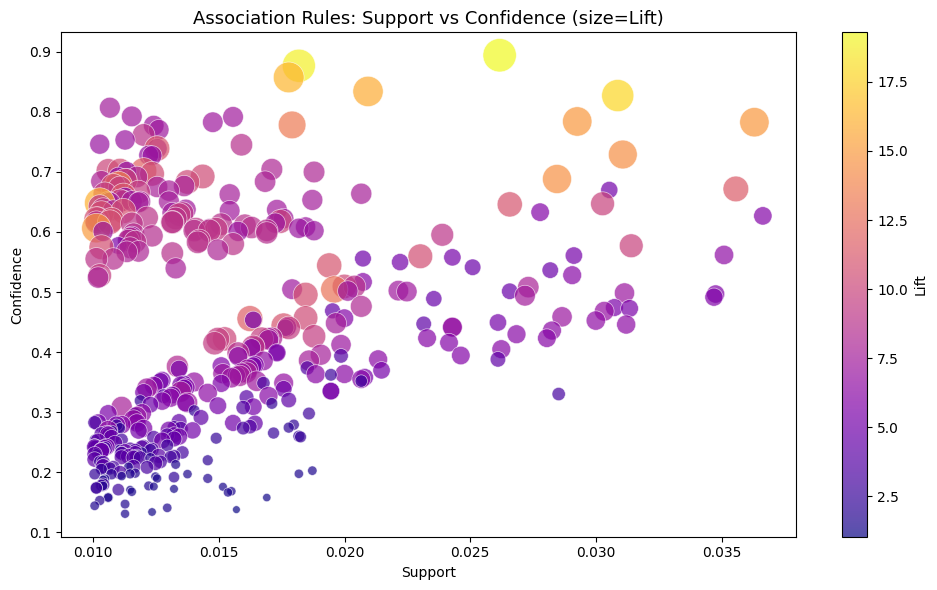


  MARKET BASKET — BUSINESS RECOMMENDATIONS
  Strong rules (lift>10, conf>0.6) : 30
  Medium rules (lift 3–10, conf>0.5): 116
  Total rules                       : 403

── Top 3 Actionable Bundles ─────────────────────────

Bundle 1:
  Buy : ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER
  Also: GREEN REGENCY TEACUP AND SAUCER
  Confidence: 89.4%  |  Lift: 19.3

Bundle 2:
  Buy : REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP AND SAUCER
  Also: GREEN REGENCY TEACUP AND SAUCER
  Confidence: 87.7%  |  Lift: 18.9

Bundle 3:
  Buy : REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP AND SAUCER
  Also: ROSES REGENCY TEACUP AND SAUCER
  Confidence: 85.8%  |  Lift: 16.3

  Market basket analysis complete.


In [69]:
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt

# ── 8e. Association Rules ─────────────────────────────────────
if len(freq_items) > 0:
    rules = association_rules(freq_items, metric="lift",
                              min_threshold=1.0)
    rules = rules.sort_values("lift", ascending=False)

    rules["antecedents_str"] = rules["antecedents"].apply(
        lambda x: ", ".join(list(x)))
    rules["consequents_str"] = rules["consequents"].apply(
        lambda x: ", ".join(list(x)))

    print("\n── Top 10 Association Rules ─────────────────────────")
    print(rules[["antecedents_str","consequents_str",
                 "support","confidence","lift"]]
          .head(10).to_string(index=False))

    # ── 8f. Deduplicate A→B / B→A ────────────────────────────
    rules["pair_key"] = rules.apply(
        lambda r: frozenset(list(r["antecedents"]) +
                            list(r["consequents"])), axis=1)
    rules_deduped = (rules.sort_values("confidence", ascending=False)
                          .drop_duplicates(subset="pair_key")
                          .drop(columns="pair_key")
                          .reset_index(drop=True))

    print(f"\nRules before dedup: {len(rules):,}")
    print(f"Rules after dedup : {len(rules_deduped):,}")

    # ── 8g. Scatter plot ─────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(
        rules_deduped["support"], rules_deduped["confidence"],
        c=rules_deduped["lift"], cmap="plasma",
        s=rules_deduped["lift"] * 30, alpha=0.7,
        edgecolors="white", linewidth=0.5
    )
    plt.colorbar(scatter, ax=ax, label="Lift")
    ax.set_xlabel("Support");  ax.set_ylabel("Confidence")
    ax.set_title("Association Rules: Support vs Confidence (size=Lift)",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig("market_basket_rules.png", dpi=150)
    plt.show()

    # ── 8h. Business recommendations ─────────────────────────
    print("\n" + "=" * 60)
    print("  MARKET BASKET — BUSINESS RECOMMENDATIONS")
    print("=" * 60)

    strong = rules_deduped[(rules_deduped["lift"] > 10) &
                            (rules_deduped["confidence"] > 0.6)]
    medium = rules_deduped[(rules_deduped["lift"].between(3, 10)) &
                            (rules_deduped["confidence"] > 0.5)]

    print(f"  Strong rules (lift>10, conf>0.6) : {len(strong):,}")
    print(f"  Medium rules (lift 3–10, conf>0.5): {len(medium):,}")
    print(f"  Total rules                       : {len(rules_deduped):,}")

    print("\n── Top 3 Actionable Bundles ─────────────────────────")
    seen = set();  count = 0
    for _, row in rules_deduped.iterrows():
        key = frozenset(list(row["antecedents"]) + list(row["consequents"]))
        if key not in seen:
            seen.add(key)
            print(f"\nBundle {count+1}:")
            print(f"  Buy : {row['antecedents_str']}")
            print(f"  Also: {row['consequents_str']}")
            print(f"  Confidence: {row['confidence']:.1%}  |  Lift: {row['lift']:.1f}")
            count += 1
        if count == 3: break

    rules_deduped[["antecedents_str","consequents_str",
                   "support","confidence","lift"]].head(20)\
        .to_csv("top_association_rules.csv", index=False)
    print("\n  Market basket analysis complete.")
else:
    print(" No frequent itemsets found. Lower min_support.")
    rules_deduped = pd.DataFrame()

In [70]:
# -------------- Predictive CLV (BG/NBD + Gamma-Gamma) --------------------

In [71]:
# CLV = Expected number of future purchases × Expected spend per purchase 
''' CLV (Customer Lifetime Value) means: The total money a customer is expected to spend with our business over their entire relationship. '''

' CLV (Customer Lifetime Value) means: The total money a customer is expected to spend with our business over their entire relationship. '

In [72]:
from lifetimes.utils import summary_data_from_transaction_data #converts raw transaction data into customer-level data
from lifetimes import BetaGeoFitter, GammaGammaFitter
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [73]:
# ──  Prepare CLV dataset ───────────────────────────────────
df_clv = df.copy()
df_clv = df_clv[df_clv["CustomerID"].notna()]
df_clv = df_clv[df_clv["TotalPrice"] > 0]
df_clv = df_clv[~df_clv["Invoice"].astype(str).str.startswith("C")]
df_clv["CustomerID"]  = df_clv["CustomerID"].astype(int)
df_clv["InvoiceDate"] = pd.to_datetime(df_clv["InvoiceDate"])

SNAPSHOT_DATE = df_clv["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {SNAPSHOT_DATE.date()}")
print(f"Clean rows   : {len(df_clv):,}")
print(f"Customers    : {df_clv['CustomerID'].nunique():,}")


Snapshot date: 2025-12-11
Clean rows   : 391,151
Customers    : 4,334


In [74]:
# ── Summary data in weeks ─────────────────────────────────
summary_raw = summary_data_from_transaction_data(
    df_clv,
    customer_id_col       = "CustomerID",
    datetime_col          = "InvoiceDate",
    monetary_value_col    = "TotalPrice",
    observation_period_end= SNAPSHOT_DATE,
    freq = "W"     # All time calculations are in weeks
)

one_time = (summary_raw["frequency"] == 0).sum()
repeat   = (summary_raw["frequency"] >  0).sum()
print(f"One-time buyers: {one_time:,} ({one_time/len(summary_raw):.1%})")
print(f"Repeat buyers  : {repeat:,} ({repeat/len(summary_raw):.1%})")


One-time buyers: 1,579 (36.4%)
Repeat buyers  : 2,755 (63.6%)


In [75]:
# ── c. Prepare repeat-buyer subset ──────────────────────────
summary_repeat = summary_raw[summary_raw["frequency"] > 0].copy()
summary_repeat = summary_repeat[
    (summary_repeat["recency"] <= summary_repeat["T"]) &
    (summary_repeat["T"] > 0) &
    (summary_repeat["monetary_value"] > 0)
].copy()

# Outlier cap: 99th pct
freq_cap = summary_repeat["frequency"].quantile(0.99)
mon_cap  = summary_repeat["monetary_value"].quantile(0.99)
summary_repeat = summary_repeat[
    summary_repeat["frequency"] <= freq_cap
].copy()
summary_repeat["monetary_value"] = summary_repeat["monetary_value"].clip(
    upper=mon_cap)

print(f"\nModelling set     : {len(summary_repeat):,} customers")
print(f"Frequency cap     : {freq_cap:.0f} orders")
print(f"Monetary cap      : £{mon_cap:.2f}")
print(f"T range (weeks)   : {summary_repeat['T'].min():.1f} – "
      f"{summary_repeat['T'].max():.1f}")



Modelling set     : 2,729 customers
Frequency cap     : 24 orders
Monetary cap      : £2270.38
T range (weeks)   : 2.0 – 100.0


In [83]:
# ──  Fit BG/NBD ───────────────────────────────────────────
bgf = None
for p in [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]:
    try:
        _bgf = BetaGeoFitter(penalizer_coef=p)
        _bgf.fit(
            summary_raw["frequency"],
            summary_raw["recency"],
            summary_raw["T"]
        )
        bgf = _bgf
        print(f"  BG/NBD fitted — penalizer={p}")
        print(bgf.summary)
        break
    except Exception as e:
        print(f"    penalizer={p} → failed: {str(e)[:60]}")
 
if bgf is None:
    raise RuntimeError("BG/NBD failed at all penalizers — check input data.")
 
# ──  diagnostic print ──────────────────────────────────
a_val = bgf.params_["a"]
b_val = bgf.params_["b"]
r_val = bgf.params_["r"]
 
print("\n── BG/NBD Parameter Diagnosis ─────────────────────────")
print(f"  r     = {r_val:.4f}  → Purchase rate shape  "
      f"{' valid' if r_val > 0.1 else ' low'}")
print(f"  alpha = {bgf.params_['alpha']:.4f}  → Purchase rate scale   valid")
print(f"  a     = {a_val:.4f}  → Dropout rate shape   "
      f"{' valid' if a_val > 0.01 else ' a≈0: no churn signal in data'}")
print(f"  b     = {b_val:.4f}  → Dropout rate scale   "
      f"{' valid' if b_val > 0.01 else ' b≈0: follows from a≈0'}")
 
if a_val < 0.01:
    print()
    print("  DIAGNOSIS: BG/NBD cannot estimate churn (a≈0)")
    print("  REASON   : ~100 week window with high customer activity.")
    print("             Almost no customers went silent → no dropout signal.")
    print("  IMPACT   : prob_alive = 1.0 for all → not usable.")
    print("  FIX      : recency-gap survival model applied in Step 9g.")
    print("  NOTE     : pred_purchases_52w is STILL VALID (uses r, alpha only).")
    bgf_churn_valid = False
else:
    print("  Churn parameters valid — prob_alive usable.")
    bgf_churn_valid = True
 

  BG/NBD fitted — penalizer=0.05
        coef  se(coef)  lower 95% bound  upper 95% bound
r      0.770     0.021            0.728            0.811
alpha 12.206     0.409           11.405           13.006
a      0.000       NaN              NaN              NaN
b      0.000       NaN              NaN              NaN

── BG/NBD Parameter Diagnosis ─────────────────────────
  r     = 0.7696  → Purchase rate shape   valid
  alpha = 12.2056  → Purchase rate scale   valid
  a     = 0.0000  → Dropout rate shape    a≈0: no churn signal in data
  b     = 0.0000  → Dropout rate scale    b≈0: follows from a≈0

  DIAGNOSIS: BG/NBD cannot estimate churn (a≈0)
  REASON   : ~100 week window with high customer activity.
             Almost no customers went silent → no dropout signal.
  IMPACT   : prob_alive = 1.0 for all → not usable.
  FIX      : recency-gap survival model applied in Step 9g.
  NOTE     : pred_purchases_52w is STILL VALID (uses r, alpha only).


In [85]:
# ──  Fit Gamma-Gamma ───────────────────────────────────────
corr = summary_repeat[["frequency","monetary_value"]].corr().iloc[0,1]
print(f"\nFrequency–Monetary correlation: {corr:.3f}  "
      f"{'OK' if abs(corr) < 0.3 else ' > 0.3'}")

ggf = None
for p in [0.0, 0.001, 0.01, 0.05, 0.1, 0.5]:
    try:
        _ggf = GammaGammaFitter(penalizer_coef=p)
        _ggf.fit(summary_repeat["frequency"],
                 summary_repeat["monetary_value"])
        ggf = _ggf
        print(f"  Gamma-Gamma converged — penalizer={p}")
        print(ggf.summary)
        break
    except Exception as e:
        print(f"    penalizer={p} → {str(e)[:70]}")

if ggf is None:
    raise RuntimeError("Gamma-Gamma failed at all penalizers.")



Frequency–Monetary correlation: 0.176  OK
  Gamma-Gamma converged — penalizer=0.0
     coef  se(coef)  lower 95% bound  upper 95% bound
p   2.363     0.140            2.088            2.638
q   3.977     0.181            3.622            4.333
v 515.306    52.162          413.069          617.544


In [86]:
# ──  Adaptive monetary cap (if too many at cap) ────────────
capped = (summary_repeat["monetary_value"] ==
          summary_repeat["monetary_value"].max()).sum()
print(f"\nCustomers at monetary cap: {capped}")
if capped > 20:
    mon_cap_new = summary_raw[summary_raw["frequency"] > 0][
        "monetary_value"].quantile(0.995)
    summary_repeat["monetary_value"] = summary_repeat[
        "monetary_value"].clip(upper=mon_cap_new)
    print(f"Recapping at 99.5th pct: £{mon_cap_new:.2f}")
    ggf2 = GammaGammaFitter(penalizer_coef=0.0)
    ggf2.fit(summary_repeat["frequency"],
             summary_repeat["monetary_value"])
    ggf = ggf2
    print("  Gamma-Gamma refitted with revised cap.")



Customers at monetary cap: 24
Recapping at 99.5th pct: £3363.34
  Gamma-Gamma refitted with revised cap.


In [87]:
# ──  Raw predictions ───────────────────────────────────────
summary_repeat["pred_purchases_52w"] = bgf.predict(
    52, summary_repeat["frequency"],
    summary_repeat["recency"], summary_repeat["T"]
)
summary_repeat["prob_alive_raw"] = bgf.conditional_probability_alive(
    summary_repeat["frequency"],
    summary_repeat["recency"], summary_repeat["T"]
)
summary_repeat["clv_12m_raw"] = ggf.customer_lifetime_value(
    bgf, summary_repeat["frequency"],
    summary_repeat["recency"], summary_repeat["T"],
    summary_repeat["monetary_value"],
    time=12, freq="W", discount_rate=0.01
)


In [88]:
# ──  Recency-gap churn adjustment (fixes a≈0 issue) ────────
summary_repeat["recency_gap"] = (summary_repeat["T"] -
                                  summary_repeat["recency"])

def survival_prob(gap_weeks):
    if   gap_weeks <= 4:  return 0.98   # bought very recently
    elif gap_weeks <= 8:  return 0.90   # warm
    elif gap_weeks <= 12: return 0.75   # at risk
    elif gap_weeks <= 26: return 0.50   # fading
    else:                 return 0.25   # likely churned

def survival_label(gap_weeks):
    if   gap_weeks <= 4:  return "Active"
    elif gap_weeks <= 8:  return "Warm"
    elif gap_weeks <= 12: return "At Risk"
    elif gap_weeks <= 26: return "Fading"
    else:                 return "Likely Churned"

summary_repeat["prob_alive_adjusted"] = summary_repeat[
    "recency_gap"].apply(survival_prob)
summary_repeat["clv_12m_adjusted"] = (
    summary_repeat["clv_12m_raw"] *
    summary_repeat["prob_alive_adjusted"]
)
summary_repeat["activity_status"] = summary_repeat[
    "recency_gap"].apply(survival_label)


In [89]:
# Print tier breakdown
print("\n=== Survival Tier Distribution ===")
tier_map = {0.98:"Active (≤4w)", 0.90:"Warm (5-8w)",
            0.75:"At Risk (9-12w)", 0.50:"Fading (13-26w)",
            0.25:"Likely Churned (>26w)"}
for prob, count in summary_repeat["prob_alive_adjusted"]\
        .value_counts().sort_index(ascending=False).items():
    print(f"  {tier_map.get(prob,'?'):<28}: {count:,}")

print(f"\nRaw CLV avg       : £{summary_repeat['clv_12m_raw'].mean():,.0f}")
print(f"Adjusted CLV avg  : £{summary_repeat['clv_12m_adjusted'].mean():,.0f}")
print(f"Raw total (12m)   : £{summary_repeat['clv_12m_raw'].sum():,.0f}")
print(f"Adjusted total    : £{summary_repeat['clv_12m_adjusted'].sum():,.0f}")
reduction = (1 - summary_repeat["clv_12m_adjusted"].sum() /
             summary_repeat["clv_12m_raw"].sum())
print(f"Churn reduction   : {reduction:.1%}")

print("\n── Top 10 by Adjusted 12-Month CLV ──────────────────")
print(summary_repeat.sort_values("clv_12m_adjusted", ascending=False)
                    .head(10)
                    [["frequency","recency","T","monetary_value",
                      "pred_purchases_52w","prob_alive_adjusted",
                      "clv_12m_raw","clv_12m_adjusted"]]
                    .round(2).to_string())



=== Survival Tier Distribution ===
  Active (≤4w)                : 1,249
  Warm (5-8w)                 : 442
  At Risk (9-12w)             : 317
  Fading (13-26w)             : 488
  Likely Churned (>26w)       : 233

Raw CLV avg       : £1,722
Adjusted CLV avg  : £1,499
Raw total (12m)   : £4,700,079
Adjusted total    : £4,091,669
Churn reduction   : 12.9%

── Top 10 by Adjusted 12-Month CLV ──────────────────
            frequency  recency       T  monetary_value  pred_purchases_52w  prob_alive_adjusted  clv_12m_raw  clv_12m_adjusted
CustomerID                                                                                                                    
14298          21.000   44.000  52.000        2270.380              17.630                0.900    35898.500         32308.650
17450          22.000   73.000  74.000        2270.380              13.730                0.980    28023.760         27463.280
18102          20.000   72.000  74.000        2270.380              12.530  

In [90]:

# -------------- Merge CLV + Churn into RFM ------------------


rfm_clv = rfm.merge(
    summary_repeat[[
        "pred_purchases_52w", "prob_alive_raw",
        "prob_alive_adjusted", "clv_12m_raw",
        "clv_12m_adjusted", "recency_gap", "activity_status"
    ]],
    left_on     = "CustomerID",   # rfm index
    right_index = True,
    how         = "left"
)

# Fill one-time buyers with 0 for Power BI
for col in ["clv_12m_raw","clv_12m_adjusted","pred_purchases_52w",
            "prob_alive_adjusted","recency_gap"]:
    rfm_clv[col] = rfm_clv[col].fillna(0)
rfm_clv["activity_status"] = rfm_clv["activity_status"].fillna(
    "One-Time Buyer")

print(f"Total customers   : {len(rfm_clv):,}")
print(f"CLV modelled      : {(rfm_clv['clv_12m_adjusted'] > 0).sum():,}")
print(f"One-time buyers   : {(rfm_clv['clv_12m_adjusted'] == 0).sum():,}")


Total customers   : 4,334
CLV modelled      : 2,729
One-time buyers   : 1,605


In [91]:
# ──  Churn risk flag ──────────────────────────────────────
def flag_churn(row):
    seg = str(row.get("segment","")).lower().replace(" ","_")
    gap = row.get("recency_gap", 0)
    if seg in ["cant_lose_them","hibernating","lost"]:
        return "High Risk"
    elif seg in ["needs_attention","about_to_sleep"]:
        return "Medium Risk"
    elif gap > 26 or row.get("activity_status") == "Likely Churned":
        return "High Risk"
    elif gap > 12 or row.get("activity_status") == "At Risk":
        return "Medium Risk"
    elif row.get("activity_status") == "One-Time Buyer":
        return "High Risk"
    else:
        return "Low Risk"

rfm_clv["churn_risk"] = rfm_clv.apply(flag_churn, axis=1)
print("\n=== Churn Risk Distribution ===")
print(rfm_clv["churn_risk"].value_counts().to_string())



=== Churn Risk Distribution ===
churn_risk
High Risk      2022
Low Risk       1597
Medium Risk     715


In [92]:
# ──  CLV tier labels ──────────────────────────────────────
repeat_mask = rfm_clv["clv_12m_adjusted"] > 0
p33 = rfm_clv.loc[repeat_mask, "clv_12m_adjusted"].quantile(0.33)
p66 = rfm_clv.loc[repeat_mask, "clv_12m_adjusted"].quantile(0.66)

def clv_tier(val):
    if val == 0:      return "No CLV (One-Time)"
    elif val <= p33:  return "Low CLV"
    elif val <= p66:  return "Mid CLV"
    else:             return "High CLV"

rfm_clv["clv_tier"] = rfm_clv["clv_12m_adjusted"].apply(clv_tier)
print(f"\nCLV thresholds — Low: £{p33:,.0f}  |  Mid: £{p66:,.0f}  |  High: £{p66:,.0f}+")
print(rfm_clv["clv_tier"].value_counts().to_string())




CLV thresholds — Low: £631  |  Mid: £1,374  |  High: £1,374+
clv_tier
No CLV (One-Time)    1605
High CLV              928
Low CLV               901
Mid CLV               900


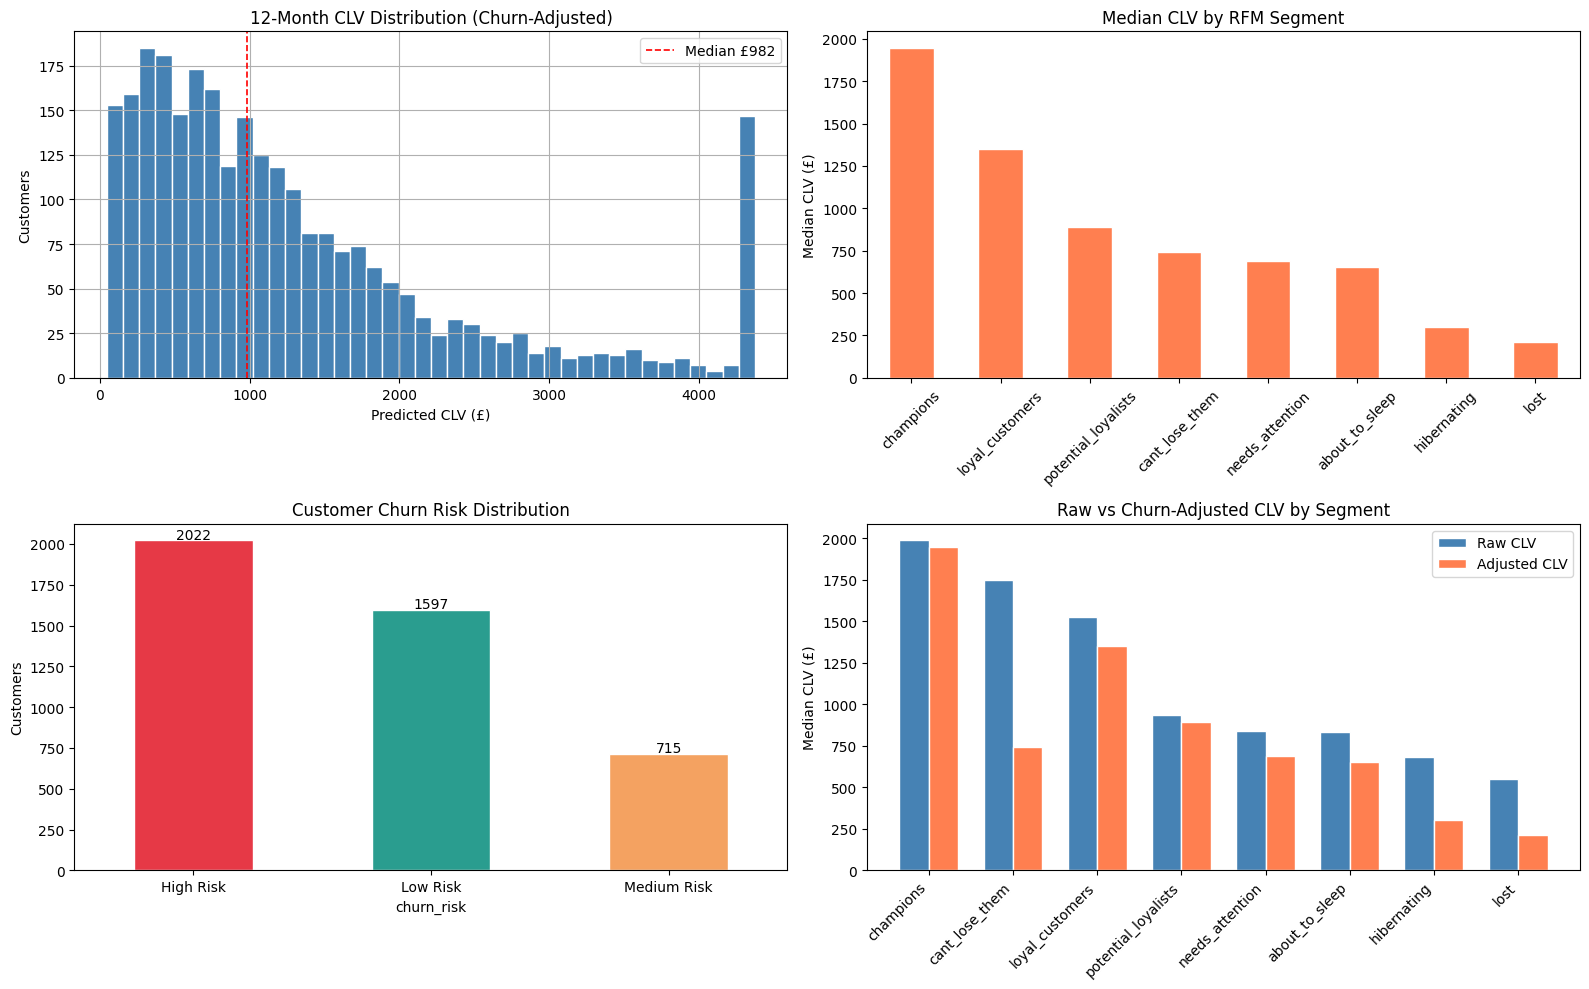

  clv_churn_dashboard.png saved.


In [93]:

#  ------------------ CLV & Churn Visualisations ---------------------------


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: CLV Distribution
repeat_clv = rfm_clv[rfm_clv["clv_12m_adjusted"] > 0]["clv_12m_adjusted"]
repeat_clv.clip(upper=repeat_clv.quantile(0.95)).hist(
    bins=40, color="steelblue", edgecolor="white", ax=axes[0,0])
axes[0,0].set_title("12-Month CLV Distribution (Churn-Adjusted)")
axes[0,0].set_xlabel("Predicted CLV (£)")
axes[0,0].set_ylabel("Customers")
axes[0,0].axvline(repeat_clv.median(), color="red", linestyle="--",
                  linewidth=1.2,
                  label=f"Median £{repeat_clv.median():,.0f}")
axes[0,0].legend()

# Plot 2: Median CLV by Segment
seg_clv = (rfm_clv[rfm_clv["clv_12m_adjusted"] > 0]
           .groupby("segment")["clv_12m_adjusted"]
           .median()
           .sort_values(ascending=False))
seg_clv.plot(kind="bar", color="coral", edgecolor="white",
             rot=45, ax=axes[0,1])
axes[0,1].set_title("Median CLV by RFM Segment")
axes[0,1].set_ylabel("Median CLV (£)")
axes[0,1].set_xlabel("")

# Plot 3: Churn Risk Distribution
churn_counts = rfm_clv["churn_risk"].value_counts()
colors_map   = {"High Risk":"#E63946","Medium Risk":"#F4A261",
                "Low Risk":"#2A9D8F"}
churn_counts.plot(
    kind="bar",
    color=[colors_map.get(c,"gray") for c in churn_counts.index],
    edgecolor="white", rot=0, ax=axes[1,0])
axes[1,0].set_title("Customer Churn Risk Distribution")
axes[1,0].set_ylabel("Customers")
for i, v in enumerate(churn_counts):
    axes[1,0].text(i, v + 10, str(v), ha="center", fontsize=10)

# Plot 4: Raw vs Adjusted CLV by Segment
compare = rfm_clv[rfm_clv["clv_12m_raw"] > 0].groupby("segment").agg(
    raw_clv      = ("clv_12m_raw",      "median"),
    adjusted_clv = ("clv_12m_adjusted", "median")
).sort_values("raw_clv", ascending=False)
x = range(len(compare));  w = 0.35
axes[1,1].bar([i - w/2 for i in x], compare["raw_clv"],
              width=w, label="Raw CLV", color="steelblue",
              edgecolor="white")
axes[1,1].bar([i + w/2 for i in x], compare["adjusted_clv"],
              width=w, label="Adjusted CLV", color="coral",
              edgecolor="white")
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(compare.index, rotation=45, ha="right")
axes[1,1].set_title("Raw vs Churn-Adjusted CLV by Segment")
axes[1,1].set_ylabel("Median CLV (£)")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("clv_churn_dashboard.png", dpi=150)
plt.show()
print("  clv_churn_dashboard.png saved.")



In [94]:
#           Model Validation & Final Summary
# ════════════════════════════════════════════════════════════════

print("\n" + "=" * 55)
print("  MODEL VALIDATION")
print("=" * 55)
print(f"BG/NBD  r     : {bgf.params_['r']:.3f}   (healthy if > 0.1)")
print(f"BG/NBD  alpha : {bgf.params_['alpha']:.3f}")
print(f"BG/NBD  a     : {bgf.params_['a']:.3f}   (WARNING if ~0)")
print(f"BG/NBD  b     : {bgf.params_['b']:.3f}")
print(f"GG      p     : {ggf.params_['p']:.3f}")
print(f"GG      q     : {ggf.params_['q']:.3f}")
print(f"GG      v     : {ggf.params_['v']:.3f}")

print(f"\nAvg predicted purchases (52w) : "
      f"{summary_repeat['pred_purchases_52w'].mean():.2f}")
print(f"Avg probability alive (adj)   : "
      f"{summary_repeat['prob_alive_adjusted'].mean():.2%}")
print(f"Avg 12-month CLV (adjusted)   : "
      f"£{summary_repeat['clv_12m_adjusted'].mean():,.0f}")
print(f"Median 12-month CLV           : "
      f"£{summary_repeat['clv_12m_adjusted'].median():,.0f}")
print(f"Total predicted revenue (12m) : "
      f"£{summary_repeat['clv_12m_adjusted'].sum():,.0f}")

print("\n" + "=" * 55)
print("  CONSUMER360 — FINAL SUMMARY")
print("=" * 55)
repeat_only = rfm_clv[rfm_clv["clv_12m_adjusted"] > 0]
print(f"Total customers            : {len(rfm_clv):,}")
print(f"Repeat buyers (CLV scored) : {len(repeat_only):,}")
print(f"One-time buyers            : {rfm_clv['clv_12m_adjusted'].eq(0).sum():,}")
print(f"\n── CLV Metrics ──")
print(f"Raw avg CLV (12m)          : £{rfm_clv['clv_12m_raw'].mean():,.0f}")
print(f"Adjusted avg CLV (12m)     : £{rfm_clv['clv_12m_adjusted'].mean():,.0f}")
print(f"Raw total revenue (12m)    : £{rfm_clv['clv_12m_raw'].sum():,.0f}")
print(f"Adjusted total (12m)       : £{rfm_clv['clv_12m_adjusted'].sum():,.0f}")
print(f"Churn discount applied     : {reduction:.1%}")
print(f"\n── Churn Risk ──")
for risk, count in rfm_clv["churn_risk"].value_counts().items():
    pct = count / len(rfm_clv) * 100
    print(f"  {risk:<15}: {count:,}  ({pct:.1f}%)")
print(f"\n── CLV Tiers ──")
for tier, count in rfm_clv["clv_tier"].value_counts().items():
    pct = count / len(rfm_clv) * 100
    print(f"  {tier:<22}: {count:,}  ({pct:.1f}%)")
print(f"\n── Activity Status ──")
for status, count in rfm_clv["activity_status"].value_counts().items():
    print(f"  {status:<20}: {count:,}")



  MODEL VALIDATION
BG/NBD  r     : 0.770   (healthy if > 0.1)
BG/NBD  alpha : 12.206
BG/NBD  a     : 0.000   (WARNING if ~0)
BG/NBD  b     : 0.000
GG      p     : 2.363
GG      q     : 3.977
GG      v     : 515.306

Avg predicted purchases (52w) : 4.21
Avg probability alive (adj)   : 79.22%
Avg 12-month CLV (adjusted)   : £1,499
Median 12-month CLV           : £982
Total predicted revenue (12m) : £4,091,669

  CONSUMER360 — FINAL SUMMARY
Total customers            : 4,334
Repeat buyers (CLV scored) : 2,729
One-time buyers            : 1,605

── CLV Metrics ──
Raw avg CLV (12m)          : £1,084
Adjusted avg CLV (12m)     : £944
Raw total revenue (12m)    : £4,700,079
Adjusted total (12m)       : £4,091,669
Churn discount applied     : 12.9%

── Churn Risk ──
  High Risk      : 2,022  (46.7%)
  Low Risk       : 1,597  (36.8%)
  Medium Risk    : 715  (16.5%)

── CLV Tiers ──
  No CLV (One-Time)     : 1,605  (37.0%)
  High CLV              : 928  (21.4%)
  Low CLV               : 901  (2